# Análisis Exploratorio — Gaming & Rendimiento Académico

In [14]:
# Importamos librerias
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Importamos el dataset y vemos sus metadatos
df = pd.read_csv("data/Gaming_Academic_performance/Gaming_Academic_Performance.csv", index_col="student_id")
display(df)

# Nos sirve para ver si hay datos vacios y su diccionario de datos
df.info()

,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
student_id,,,,,,,,,,,,,
1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7991,20,Male,6.02,5.29,6.73,64.56,Casual,4.77,7.43,231.47,11.63,Low,39.590000
7992,22,Female,1.22,9.14,4.34,93.97,Casual,4.81,4.22,308.25,5.41,High,105.211520
7993,21,Female,3.17,6.18,6.54,69.78,Casual,0.95,7.22,288.80,7.07,Medium,81.160000


<class 'pandas.DataFrame'>
RangeIndex: 7995 entries, 1 to 7995
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               7995 non-null   int64  
 1   gender            7995 non-null   str    
 2   gaming_hours      7995 non-null   float64
 3   study_hours       7995 non-null   float64
 4   sleep_hours       7995 non-null   float64
 5   attendance        7995 non-null   float64
 6   gaming_genre      7995 non-null   str    
 7   social_activity   7995 non-null   float64
 8   device_usage      7995 non-null   float64
 9   reaction_time_ms  7995 non-null   float64
 10  addiction_score   7995 non-null   float64
 11  stress_level      7995 non-null   str    
 12  grades            7995 non-null   float64
dtypes: float64(9), int64(1), str(3)
memory usage: 812.1 KB


## 1. Medidas de Tendencia Central y Dispersión

In [16]:
numeric_cols = ['gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
                'social_activity', 'device_usage', 'reaction_time_ms',
                'addiction_score', 'grades']

stats = df[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
stats.columns = ['Media', 'Mediana', 'Desv. Est.', 'Mínimo', 'Máximo']
stats['Moda'] = df[numeric_cols].mode().iloc[0]
stats = stats.round(2)

display(stats)

,Media,Mediana,Desv. Est.,Mínimo,Máximo,Moda
gaming_hours,4.09,4.13,2.31,0.00,8.00,6.23
study_hours,5.46,5.46,2.58,1.00,10.00,1.67
sleep_hours,6.49,6.50,1.44,4.00,9.00,7.68
attendance,79.89,79.70,11.58,60.00,100.00,71.40
social_activity,2.51,2.50,1.44,0.00,5.00,2.26
device_usage,7.59,7.61,2.71,1.10,13.95,7.68
reaction_time_ms,271.10,270.47,29.44,183.26,347.87,239.33
addiction_score,9.91,10.01,5.04,-4.51,23.16,9.34
grades,66.18,67.09,22.42,0.00,118.63,100.00


## 2. Distribución de Calificaciones

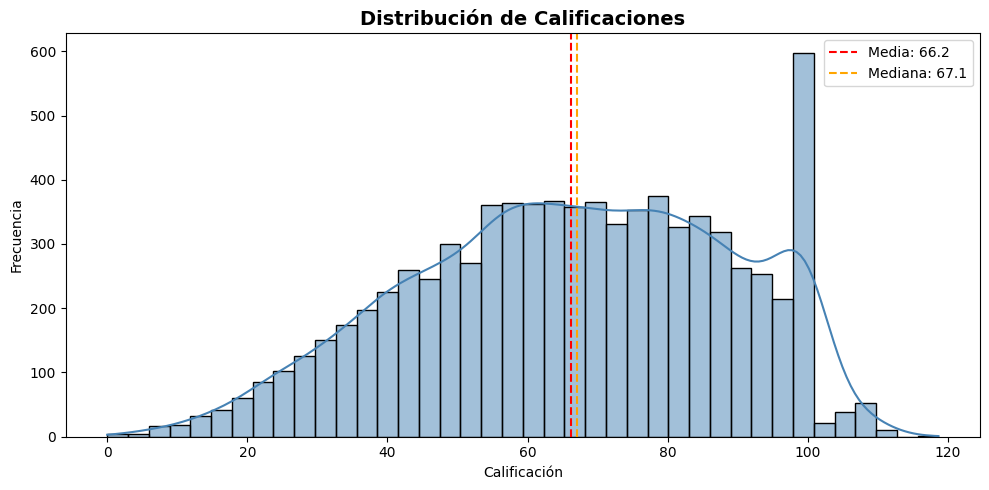

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['grades'], bins=40, kde=True, color='steelblue', ax=ax)
ax.axvline(df['grades'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Media: {df['grades'].mean():.1f}")
ax.axvline(df['grades'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Mediana: {df['grades'].median():.1f}")
ax.set_title('Distribución de Calificaciones', fontsize=14, fontweight='bold')
ax.set_xlabel('Calificación')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('graficos/01_distribucion_calificaciones.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Horas de Juego vs Calificación

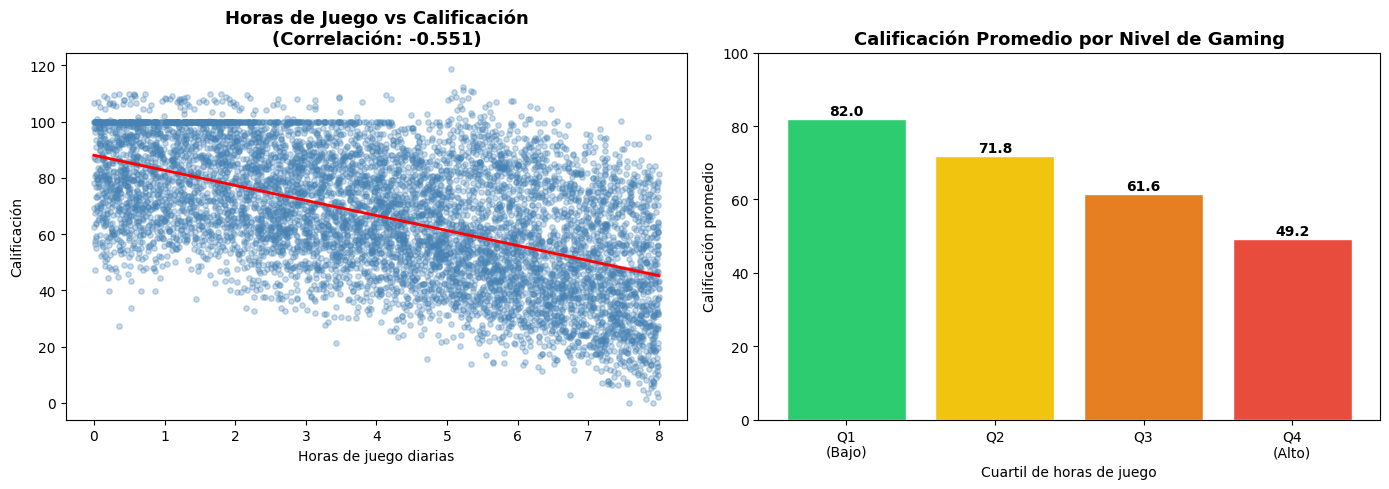

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x='gaming_hours', y='grades', ax=axes[0],
            scatter_kws={'alpha': 0.3, 'color': 'steelblue', 's': 15},
            line_kws={'color': 'red', 'linewidth': 2})
corr = df['gaming_hours'].corr(df['grades'])
axes[0].set_title(f'Horas de Juego vs Calificación\n(Correlación: {corr:.3f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Horas de juego diarias')
axes[0].set_ylabel('Calificación')

df['gaming_quartile'] = pd.qcut(df['gaming_hours'], q=4, labels=['Q1\n(Bajo)', 'Q2', 'Q3', 'Q4\n(Alto)'])
mean_grades = df.groupby('gaming_quartile', observed=True)['grades'].mean()
bars = axes[1].bar(mean_grades.index, mean_grades.values,
                   color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'], edgecolor='white')
axes[1].set_title('Calificación Promedio por Nivel de Gaming', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cuartil de horas de juego')
axes[1].set_ylabel('Calificación promedio')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars, mean_grades.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graficos/02_gaming_vs_calificacion.png', dpi=150, bbox_inches='tight')
plt.show()
df.drop(columns=['gaming_quartile'], inplace=True)

## 4. Mapa de Calor — Correlaciones entre Variables

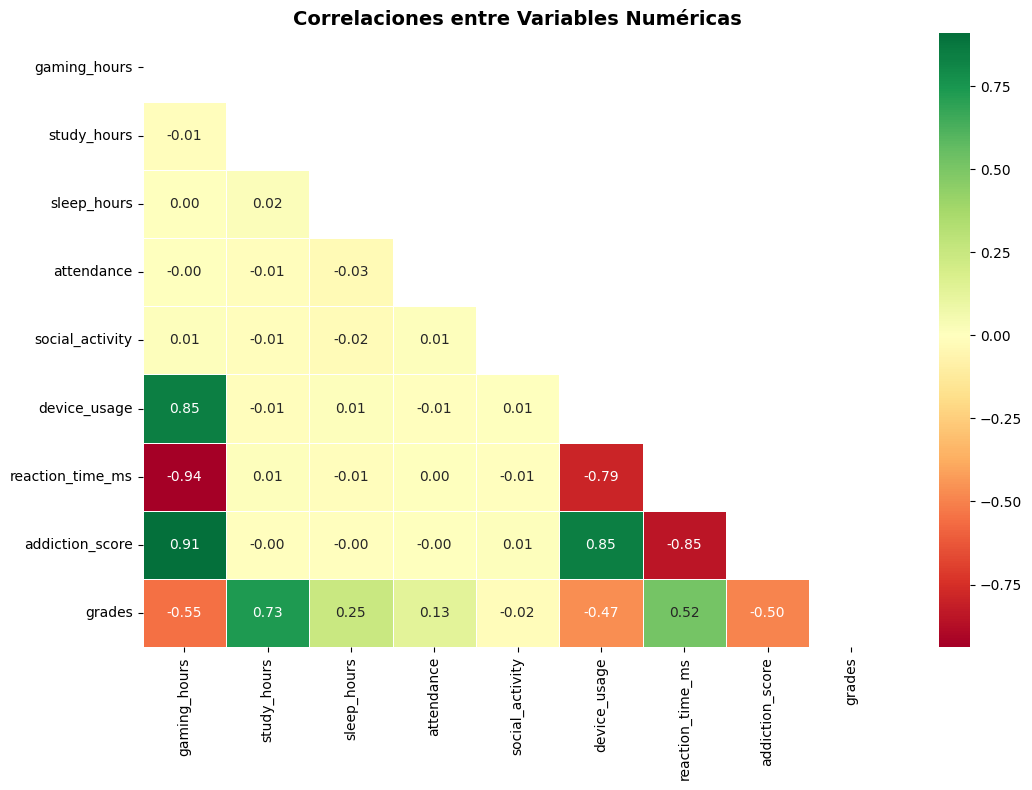

In [19]:
numeric_cols = ['gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
                'social_activity', 'device_usage', 'reaction_time_ms',
                'addiction_score', 'grades']

fig, ax = plt.subplots(figsize=(11, 8))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Correlaciones entre Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/03_heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Calificación por Nivel de Estrés y Género de Juego

/var/folders/8q/kpr1c3bd783bcqg85qsy39hr0000gn/T/ipykernel_17827/257786821.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stress_level', y='grades', order=stress_order,


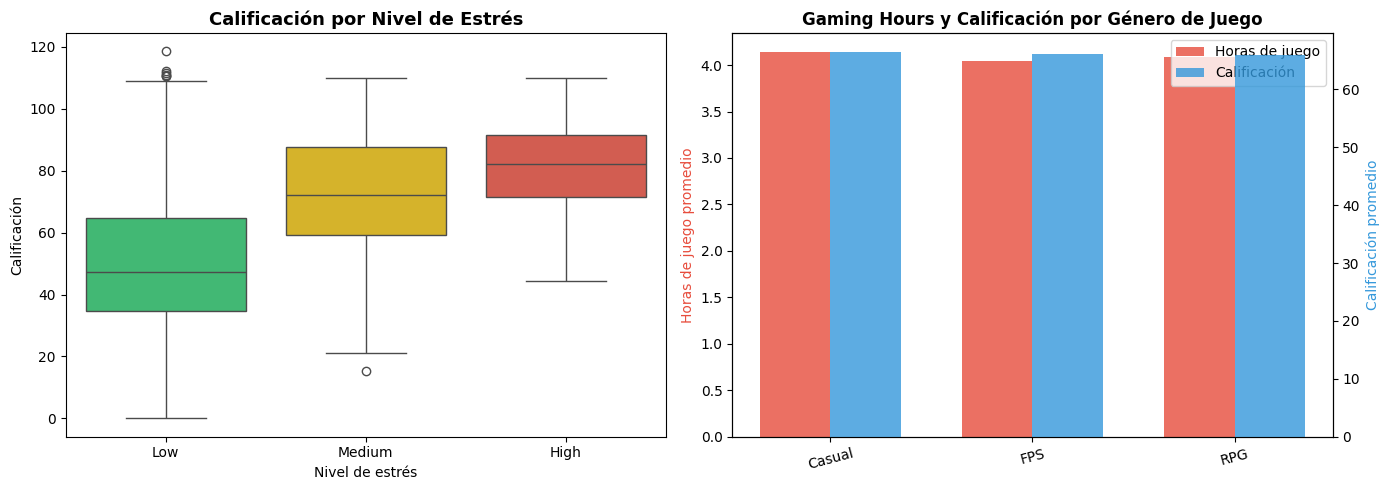

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stress_order = ['Low', 'Medium', 'High']
sns.boxplot(data=df, x='stress_level', y='grades', order=stress_order,
            palette=['#2ecc71', '#f1c40f', '#e74c3c'], ax=axes[0])
axes[0].set_title('Calificación por Nivel de Estrés', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nivel de estrés')
axes[0].set_ylabel('Calificación')

genre_stats = (df.groupby('gaming_genre')[['gaming_hours', 'grades']]
               .mean().round(2).sort_values('grades', ascending=False))
x = range(len(genre_stats))
width = 0.35
axes[1].bar([i - width/2 for i in x], genre_stats['gaming_hours'], width,
            label='Horas de juego', color='#e74c3c', alpha=0.8)
ax2 = axes[1].twinx()
ax2.bar([i + width/2 for i in x], genre_stats['grades'], width,
        label='Calificación', color='#3498db', alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(genre_stats.index, rotation=15)
axes[1].set_ylabel('Horas de juego promedio', color='#e74c3c')
ax2.set_ylabel('Calificación promedio', color='#3498db')
axes[1].set_title('Gaming Hours y Calificación por Género de Juego', fontsize=12, fontweight='bold')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('graficos/04_estres_y_genero.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Top Variables Correlacionadas con Calificación

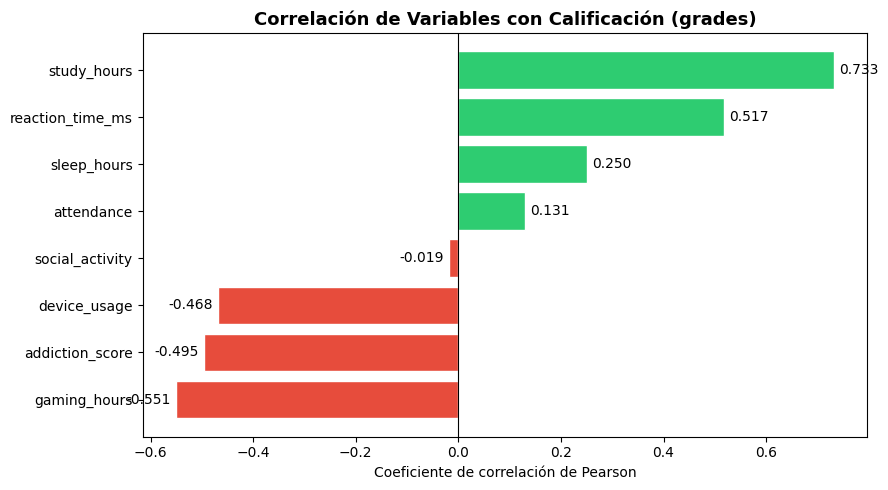

In [21]:
numeric_cols = ['gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
                'social_activity', 'device_usage', 'reaction_time_ms',
                'addiction_score', 'grades']

correlaciones = df[numeric_cols].corr()['grades'].drop('grades').sort_values()

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in correlaciones]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(correlaciones.index, correlaciones.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, correlaciones.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
ax.set_title('Correlación de Variables con Calificación (grades)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente de correlación de Pearson')
plt.tight_layout()
plt.savefig('graficos/05_correlaciones_con_grades.png', dpi=150, bbox_inches='tight')
plt.show()